In [22]:
import os
import sys
from os.path import join
import copy

# Add parent directory (arch/) to path so we can import sibling modules
# Handle both cases: notebook run from diagnostics/ or from arch/
current_dir = os.getcwd()
if 'diagnostics' in current_dir:
    arch_dir = os.path.dirname(current_dir)
else:
    arch_dir = current_dir

if arch_dir not in sys.path:
    sys.path.insert(0, arch_dir)
    
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import corner
import torch
import torch.multiprocessing as mp
from torch.distributed import init_process_group, destroy_process_group
from torch.utils.data.distributed import DistributedSampler
from torch.utils.data import DataLoader, Subset
from astropy.io import fits
import pyxis.torch as pxt
import pyxis as px
import galsim as gs

from networks import ForkCNN
from train import (
    load_model,
    apply_noise,
)
import config
from utils import (
    denormalize,
    make_corner_plot,
)

stem = 'CNN-CNN-flow'
data_dir = '/ocean/projects/phy250048p/shared/datasets/valid_1m'
samp_dir = '/ocean/projects/phy250048p/shared/samples/samples_valid_1m.csv'
fig_dir = '/ocean/projects/phy250048p/shared/figures/'
model_dir = f'/ocean/projects/phy250048p/shared/models/{stem}/'
loss_dir = '/ocean/projects/phy250048p/shared/models/losses/'
results_dir = '/ocean/projects/phy250048p/shared/results/'
cache_dir = '/ocean/projects/phy250048p/shared/cache/'

In [23]:
plt.rcParams.update({"text.usetex": False, "font.family": "serif", "figure.dpi": 300})
os.makedirs(join(fig_dir, stem), exist_ok=True)

In [24]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [53]:
# Get data loader
bs = 1000
test_args = list(config.test.values())
test_ds = pxt.TorchDataset(data_dir)
test_dl = DataLoader(test_ds,
                     batch_size=bs,
                     pin_memory=False,
                     shuffle=False,)
nsub = 100000
subset = Subset(test_ds, np.arange(0, nsub))
sub_dl = DataLoader(subset,
                    batch_size=bs,
                    pin_memory=False,
                    shuffle=False,)

In [58]:
snrs = torch.rand((nsub,), device=device)*995 + 5
stacked_img = torch.zeros_like(test_ds[0]['img'], device=device)
for i, batch in enumerate(sub_dl):
    stacked_img += torch.sum(apply_noise(batch['img'].float().to(device), snrs[i], device=device), dim=0)
stacked_img = stacked_img.cpu().numpy()[0]
stacked_img /= np.max(stacked_img)

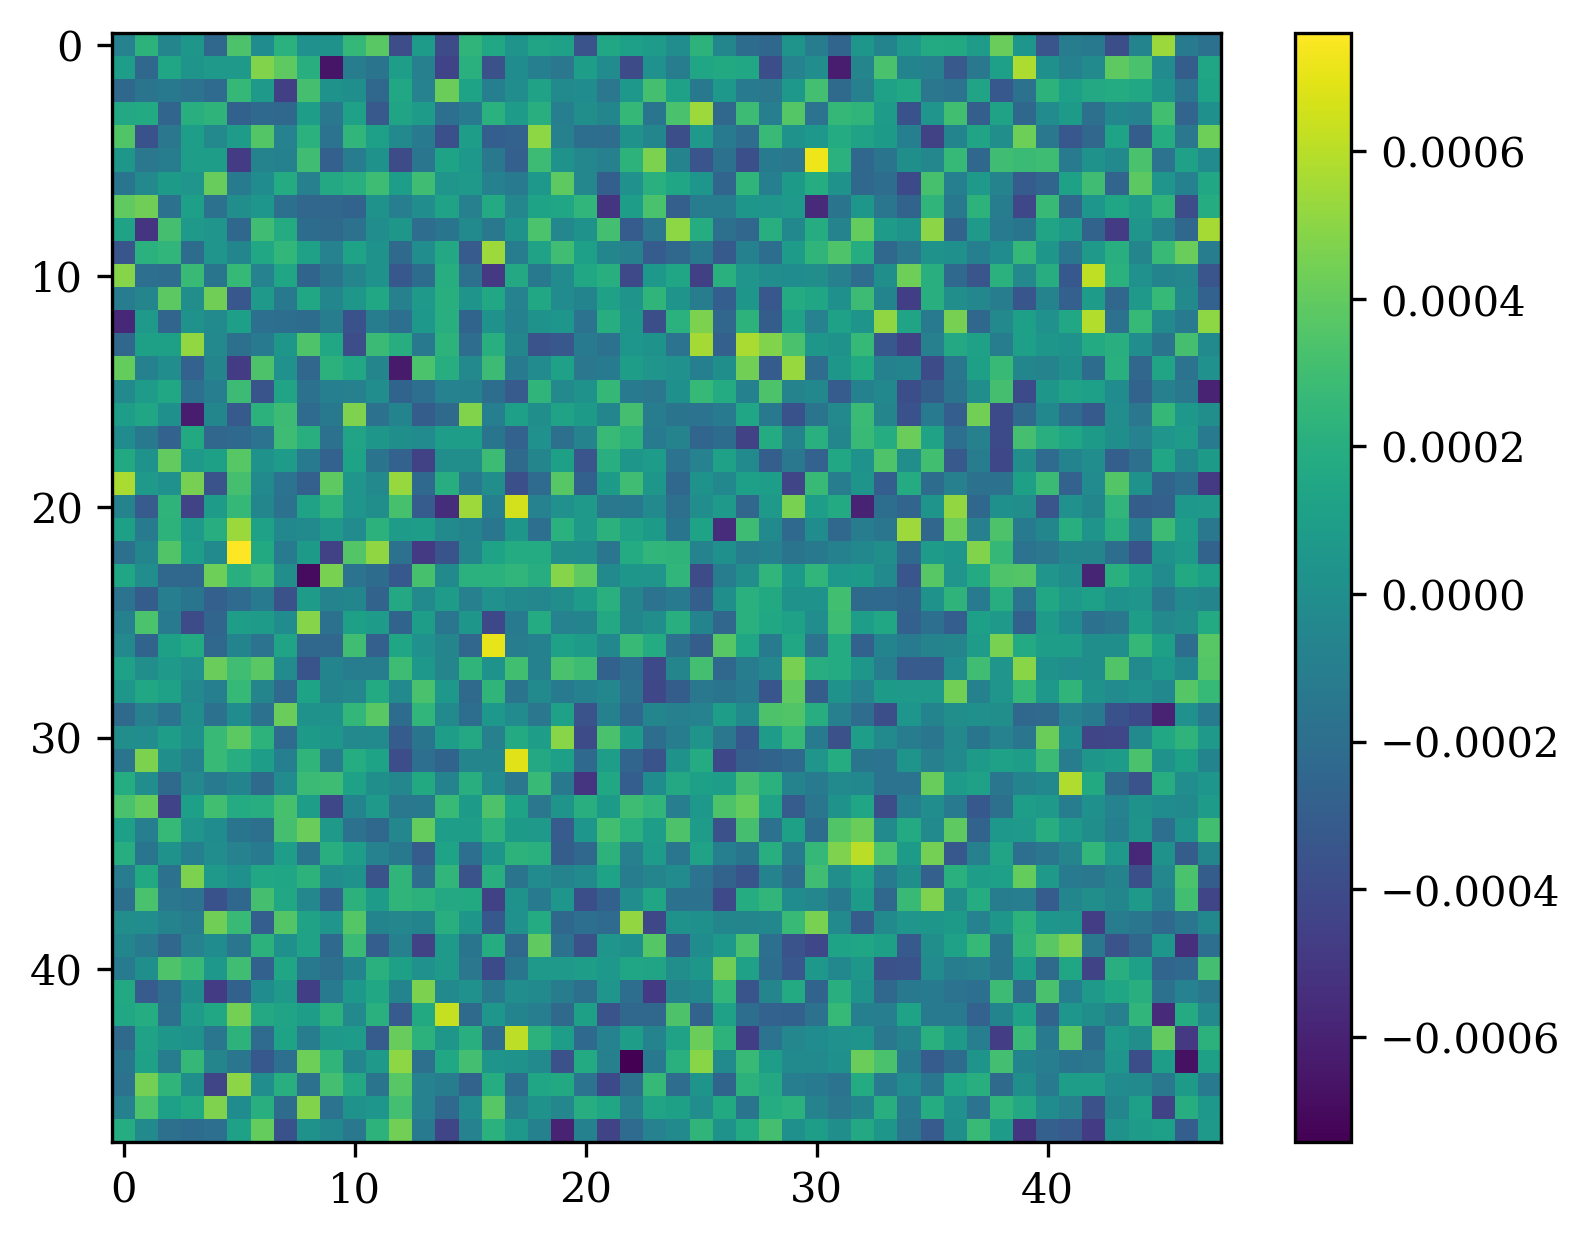

In [59]:
stacked_img_rot90 = np.rot90(stacked_img)
diff_img_90 = stacked_img - stacked_img_rot90
plt.imshow(diff_img_90)
plt.colorbar()

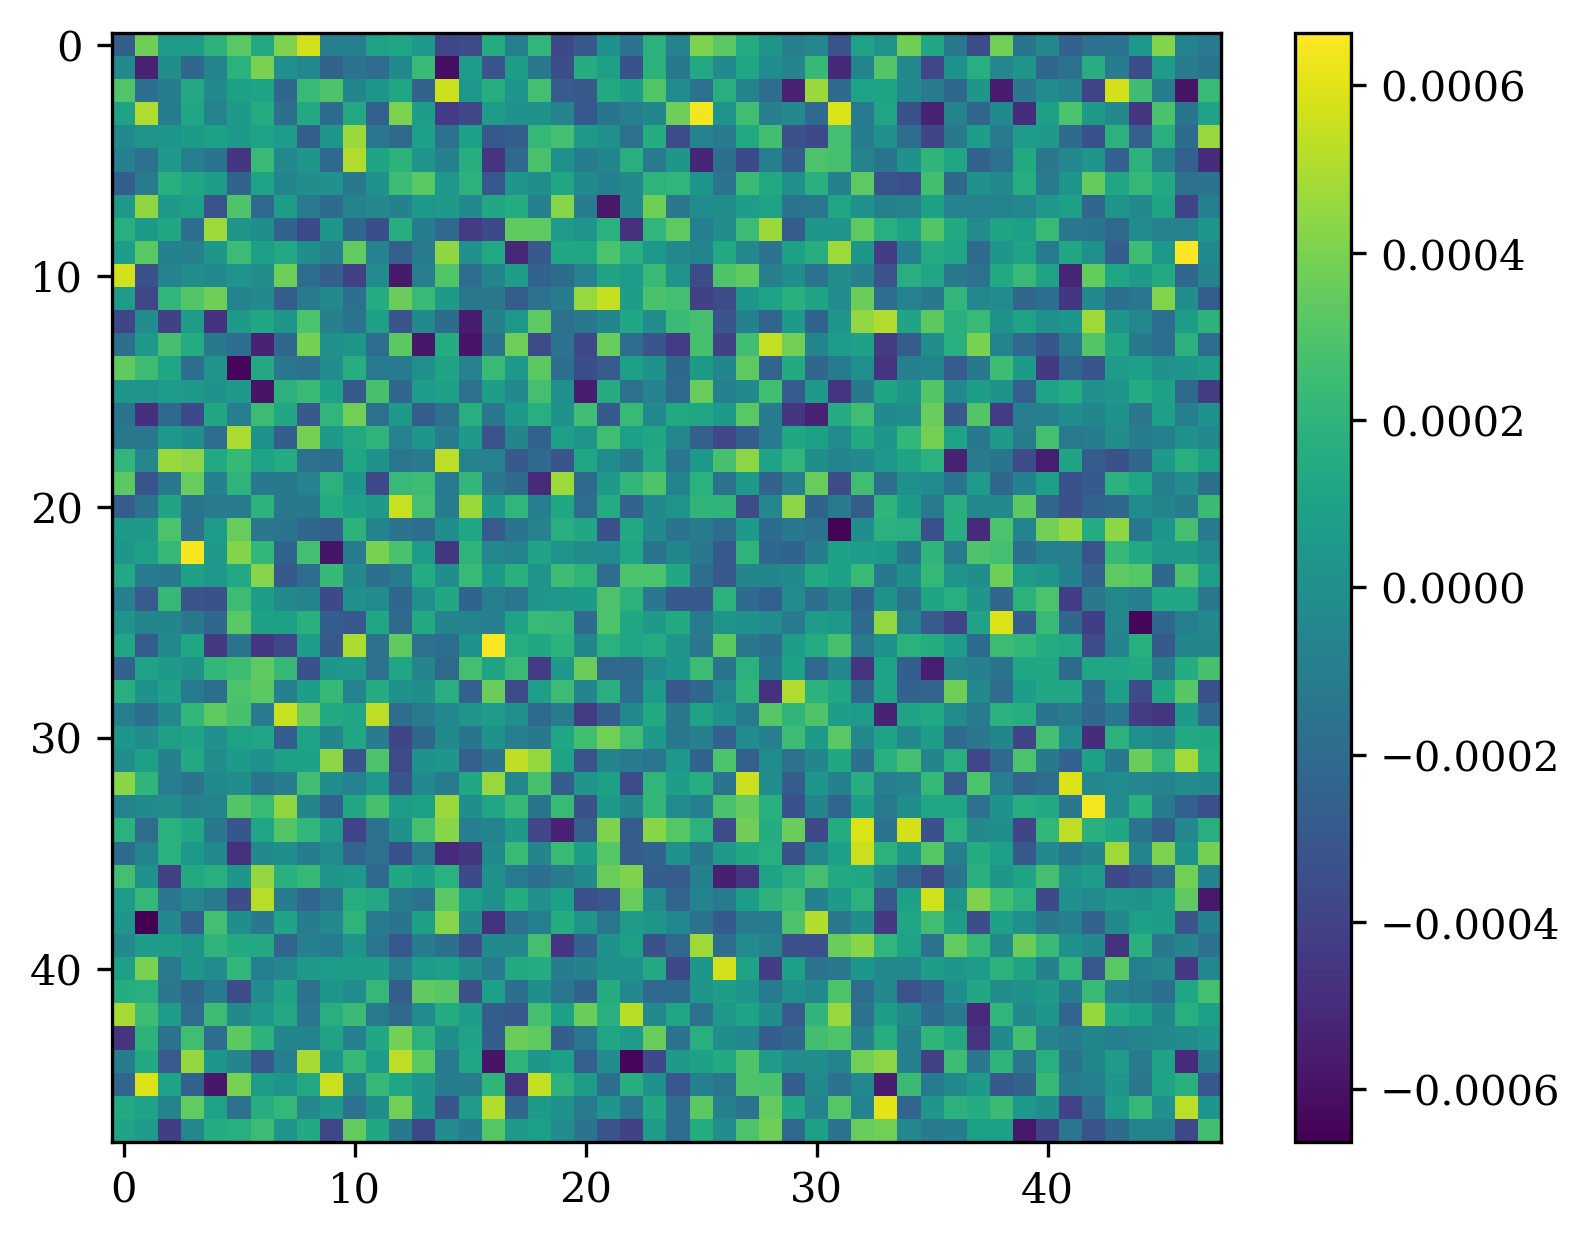

In [60]:
stacked_img_rot180 = np.rot90(stacked_img, k=2)
diff_img = stacked_img - stacked_img_rot180
plt.imshow(diff_img)
plt.colorbar()

In [62]:
stacked_img_gs = gs.Image(stacked_img)

In [63]:
shape_data = gs.hsm.FindAdaptiveMom(stacked_img_gs)

In [64]:
print(shape_data.observed_shape)
print(shape_data.moments_sigma)
print(shape_data.moments_centroid)
print(shape_data.moments_rho4)

galsim.Shear(g1=0.00010264683207374471,g2=4.517283434749789e-05)
2.933788537979126
galsim.PositionD(24.49973247444115,24.500050115469417)
2.4237551831203428


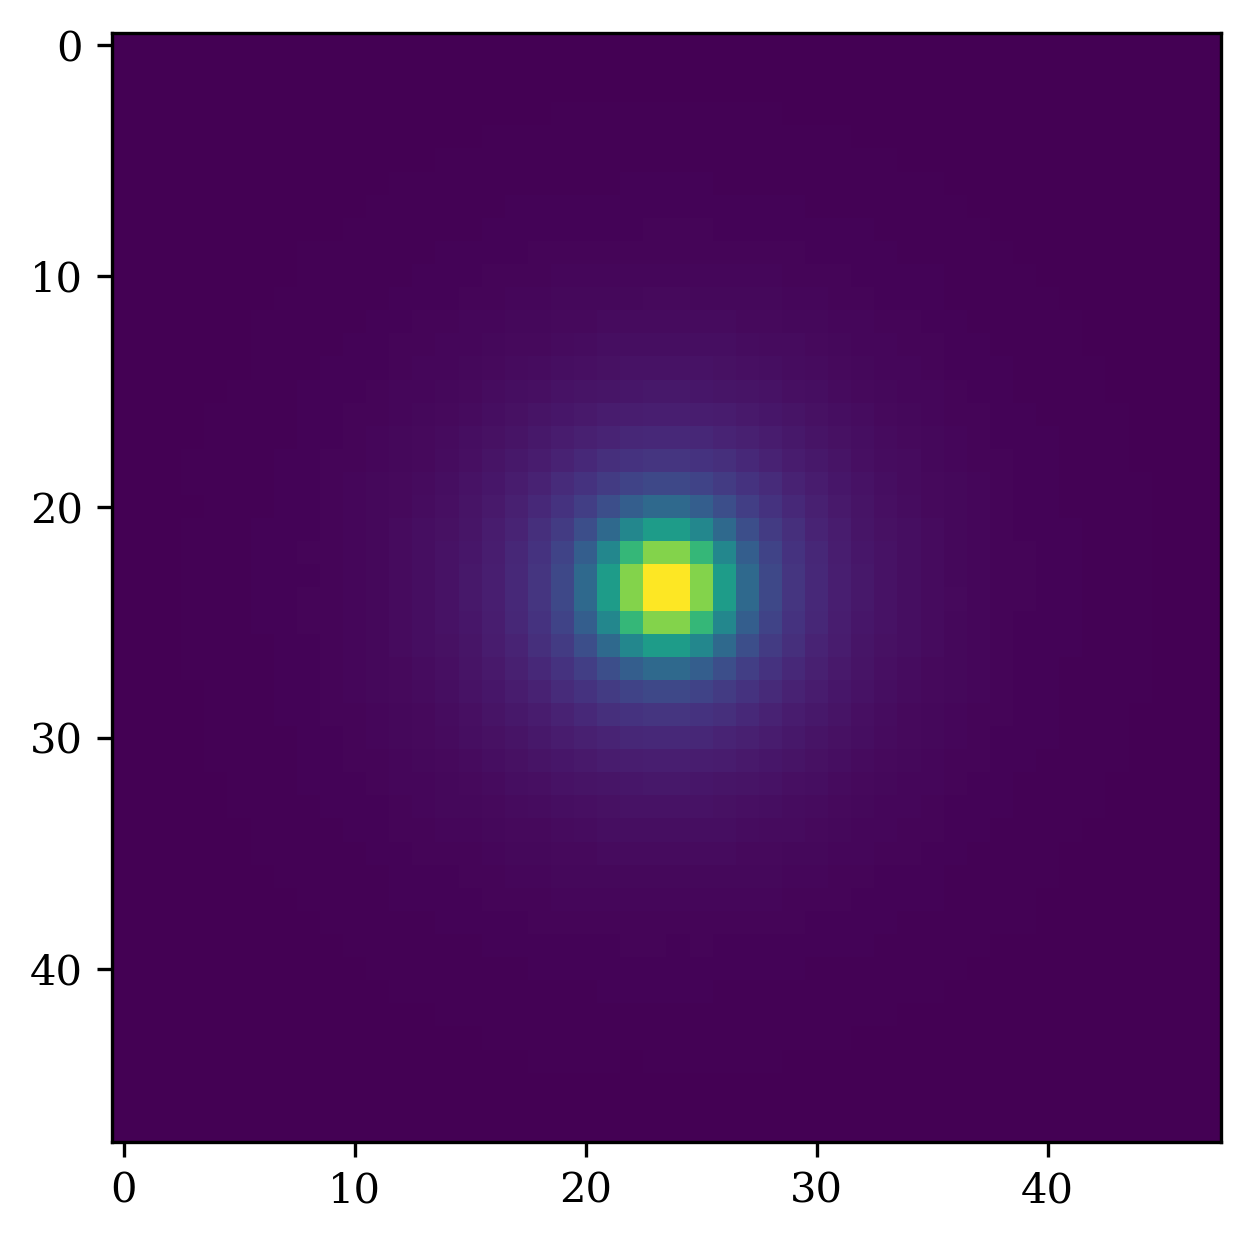

In [61]:
plt.imshow(stacked_img)